<a href="https://colab.research.google.com/github/Jerrythemouse1903/B-i-t-p-tu-n-1/blob/main/B%C3%A0i_t%E1%BA%ADp_tu%E1%BA%A7n_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

23.1


In [ ]:
from geopy.geocoders import Nominatim
import folium

geolocator= Nominatim(user_agent= "colab-map-demo", timeout =10)
address_UEH="279 Nguyen Tri Phuong, Dien Hong, Ho Chi Minh City"
location_UEH = geolocator.geocode(address_UEH)
latlng_UEH = (location_UEH.latitude, location_UEH.longitude)
m=folium.Map(location=latlng_UEH, zoom_start =13)
folium.Marker(latlng_UEH, popup = "Đại học kinh tế Hồ Chí Minh", icon=folium.Icon(color='red')).add_to(m)
address_Vanhanhmall ="11 Su Van Hanh, Hoa Hung, Ho CHi Minh City"
location_Vanhanhmall= geolocator.geocode(address_Vanhanhmall)
latlng_Vanhanhmall= (location_Vanhanhmall.latitude, location_Vanhanhmall.longitude)
folium.Marker(latlng_Vanhanhmall, popup = "Vạn Hạnh Mall", icon=folium.Icon(color='red')).add_to(m)
address_LTTpark= "1 Ly Thai To, Vuon Lai, Ho Chi Minh City"
location_LTTpark= geolocator.geocode(address_LTTpark)
latlng_LTTpark= (location_LTTpark.latitude, location_LTTpark.longitude)
folium.Marker(latlng_LTTpark, popup = "Công viên Lý Thái Tổ", icon=folium.Icon(color='red')).add_to(m)
address_NTPHos = "468 Nguyen Trai, An Dong, Ho Chi Minh City"
location_NTPHos= geolocator.geocode(address_NTPHos)
latlng_NTPHos= (location_NTPHos.latitude, location_NTPHos.longitude)
folium.Marker(latlng_NTPHos, popup = "Bệnh viện Nguyễn Tri Phương", icon=folium.Icon(color='red')).add_to(m)
address_VNQT= "244 3/2, Hoa Hung, Ho Chi Minh City"
location_VNQT= geolocator.geocode(address_VNQT)
latlng_VNQT= (location_VNQT.latitude, location_VNQT.longitude)
folium.Marker(latlng_VNQT, popup = "Việt Nam Quốc Tự", icon=folium.Icon(color='red')).add_to(m)
address_HoaBinhsta= "240 3/2, Hoa Hung, Ho CHi Minh City"
location_HoaBinhsta= geolocator.geocode(address_HoaBinhsta)
latlng_HoaBinhsta= (location_HoaBinhsta.latitude, location_HoaBinhsta.longitude)
folium.Marker(latlng_HoaBinhsta, popup = "Nhà hát Hòa Bình", icon=folium.Icon(color='red')).add_to(m)

m


23.2

In [ ]:
from geopy.distance import geodesic
import folium
from geopy.geocoders import Nominatim
geolocator=Nominatim(user_agent="colab-map-demo")
address_UEH="279 Nguyen Tri Phuong, Dien Hong, Ho Chi Minh City"
location_UEH = geolocator.geocode(address_UEH)
latlng_UEH = (location_UEH.latitude, location_UEH.longitude)
m=folium.Map(location=UEH, zoom_start=13)
folium.Marker(UEH, popup="UEH Campus B", icon=folium.Icon(color="red")).add_to(m)
locations= [
    {"name": "Vạn Hạnh Mall",
     "address": "11 Su Van Hanh, Hoa Hung, Ho Chi Minh City",
     },
    {"name": "Công Viên Lý Thái Tổ",
     "address": "1 Ly Thai To, Vuon Lai, Ho Chi Minh City"},
    {"name": "Nhà hát Hòa Binh",
     "address": "240 3/2, Hoa Hung, Ho Chi Minh City"},
    {"name": "Việt Nam quốc tự",
     "address": "244 3/2, Hoa Hung, Ho Chi Minh City"},
    {"name": "Quán chay Thôi Kệ",
    "address": "725 Le Hong Phong, Hoa Hung, Ho Chi Minh City"}
]
for loc in locations:
  location_data= geolocator.geocode(loc['address'])
  latlng_locations = (location_data.latitude, location_data.longitude)
  dist=geodesic(latlng_UEH, latlng_locations)
  print(f"{loc["name"]}: {dist} từ UEH")
  folium.Marker(location=latlng_locations,
              popup=folium.Popup(f"{loc["name"]}"),
                icon=folium.Icon(color="red")).add_to(m)
  folium.Polygon(locations=[latlng_UEH, latlng_locations], color="green", fill=True).add_to(m)
m

Vạn Hạnh Mall: 0.5757503164466771 km từ UEH
Công Viên Lý Thái Tổ: 0.8912084205872605 km từ UEH
Nhà hát Hòa Binh: 1.7447384817081182 km từ UEH
Việt Nam quốc tự: 0.5289448887026137 km từ UEH
Quán chay Thôi Kệ: 0.8326798369998526 km từ UEH


In [ ]:
23.3

In [ ]:
from folium.plugins import HeatMap
m=folium.Map(location=[10.7611,106.6684])
heat_data=[
    [10.770226992325739, 106.66820031480081], #Vạn Hạnh Mall
    [10.7721, 106.6598], # Bách Khoa
    [10.7745, 106.6784], # Nhà hát Hòa Bình
]
HeatMap(heat_data).add_to(m)
m

23.4


In [ ]:
import pandas as pd
import folium
import json

# 1. Đọc dữ liệu (Giữ nguyên file CSV của bạn)
state_data = pd.read_csv('region_data_23_4.csv')

# Đổi tên cột 'Region' trong CSV thành 'Thành phố' để đồng nhất theo ý bạn
state_data.rename(columns={'Region': 'Thành phố'}, inplace=True)

# 2. Đọc file GeoJSON
with open('vn.json', 'r', encoding='utf-8') as f:
    vn_geo = json.load(f)

# 3. Bảng Mapping (Bắt buộc phải có để máy biết tỉnh nào thuộc vùng nào)
province_to_region = {
    'An Giang': 'Đồng bằng sông Cửu Long', 'Bà Rịa - Vũng Tàu': 'Đông Nam Bộ',
    'Bình Dương': 'Đông Nam Bộ', 'Bình Phước': 'Đông Nam Bộ',
    'Bình Thuận': 'Duyên hải Nam Trung Bộ', 'Bình Định': 'Duyên hải Nam Trung Bộ',
    'Bạc Liêu': 'Đồng bằng sông Cửu Long', 'Bắc Giang': 'Trung du và miền núi Bắc Bộ',
    'Bắc Ninh': 'Đồng bằng sông Hồng', 'Bến Tre': 'Đồng bằng sông Cửu Long',
    'Can Tho': 'Đồng bằng sông Cửu Long', 'Cao Bằng': 'Trung du và miền núi Bắc Bộ',
    'Cà Mau': 'Đồng bằng sông Cửu Long', 'Gia Lai': 'Tây Nguyên',
    'Ha Noi': 'Đồng bằng sông Hồng', 'Ha Tinh': 'Bắc Trung Bộ',
    'Hau Giang': 'Đồng bằng sông Cửu Long', 'Hà Giang': 'Trung du và miền núi Bắc Bộ',
    'Hà Nam': 'Đồng bằng sông Hồng', 'Hòa Bình': 'Trung du và miền núi Bắc Bộ',
    'Hải Dương': 'Đồng bằng sông Hồng', 'Hải Phòng': 'Đồng bằng sông Hồng',
    'Hồ Chí Minh city': 'Đông Nam Bộ', 'Khánh Hòa': 'Duyên hải Nam Trung Bộ',
    'Kiên Giang': 'Đồng bằng sông Cửu Long', 'Kon Tum': 'Tây Nguyên',
    'Lai Chau': 'Trung du và miền núi Bắc Bộ', 'Long An': 'Đồng bằng sông Cửu Long',
    'Lào Cai': 'Trung du và miền núi Bắc Bộ', 'Lâm Đồng': 'Tây Nguyên',
    'Lạng Sơn': 'Trung du và miền núi Bắc Bộ', 'Nam Định': 'Đồng bằng sông Hồng',
    'Nghệ An': 'Bắc Trung Bộ', 'Ninh Bình': 'Đồng bằng sông Hồng',
    'Ninh Thuận': 'Duyên hải Nam Trung Bộ', 'Phú Thọ': 'Trung du và miền núi Bắc Bộ',
    'Phú Yên': 'Duyên hải Nam Trung Bộ', 'Quàng Nam': 'Duyên hải Nam Trung Bộ',
    'Quảng Bình': 'Bắc Trung Bộ', 'Quảng Ngãi': 'Duyên hải Nam Trung Bộ',
    'Quảng Ninh': 'Trung du và miền núi Bắc Bộ', 'Quảng Trị': 'Bắc Trung Bộ',
    'Son La': 'Trung du và miền núi Bắc Bộ', 'Sóc Trăng': 'Đồng bằng sông Cửu Long',
    'Thanh Hóa': 'Bắc Trung Bộ', 'Thái Bình': 'Đồng bằng sông Hồng',
    'Thái Nguyên': 'Trung du và miền núi Bắc Bộ', 'Thừa Thiên - Huế': 'Bắc Trung Bộ',
    'Tiền Giang': 'Đồng bằng sông Cửu Long', 'Trà Vinh': 'Đồng bằng sông Cửu Long',
    'Tuyên Quang': 'Trung du và miền núi Bắc Bộ', 'Tây Ninh': 'Đông Nam Bộ',
    'Vĩnh Long': 'Đồng bằng sông Cửu Long', 'Vĩnh Phúc': 'Đồng bằng sông Hồng',
    'Yên Bái': 'Trung du và miền núi Bắc Bộ', 'Ðong Tháp': 'Đồng bằng sông Cửu Long',
    'Điện Biên': 'Trung du và miền núi Bắc Bộ', 'Đà Nẵng': 'Duyên hải Nam Trung Bộ',
    'Đông Bắc': 'Trung du và miền núi Bắc Bộ', 'Đông Nam Bộ': 'Đông Nam Bộ',
    'Đắk Lắk': 'Tây Nguyên', 'Đắk Nông': 'Tây Nguyên', 'Đồng Bằng Sông Hồng': 'Đồng bằng sông Hồng'
}

# 4. ĐỒNG NHẤT: Thêm thuộc tính 'Thành phố' trực tiếp vào dữ liệu GeoJSON
for feature in vn_geo['features']:
    p_name = feature['properties']['name']
    # Gán tên vùng vào thuộc tính 'Thành phố' của tỉnh đó ngay trong cấu trúc GeoJSON
    feature['properties']['Thành phố'] = province_to_region.get(p_name)

# 5. Vẽ bản đồ: Dùng trực tiếp state_data
m = folium.Map(location=[16, 108], zoom_start=6)

folium.Choropleth(
    geo_data=vn_geo,
    name="choleropeth",
    data=state_data,
    columns=["Thành phố", "Population_Density"],
    key_on="feature.properties.Thành phố",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Chỉ số phân tích vùng"
).add_to(m)
m

23.5

In [ ]:
from geopy.distance import geodesic
import folium
from geopy.geocoders import Nominatim
geolocator= Nominatim(user_agent="colab-map-demo", timeout=10)
m= folium.Map(location=[10.77361,106.66722], zoom_start=13)
warehouse=[
    ("Circle K Sư Vạn Hạnh","704 Su Van Hanh, Hoa Hung, Ho Chi Minh City"),
    ("Circle K Cao Thắng", "306 Cao Thang, Hoa Hung, Ho Chi Minh City"),
    ("Circle K Cách Mạng tháng 8", "285/94 Cach Mang Thang 8, Hoa Hung, Ho Chi Minh City")
]
for name, address in warehouse:
  address_location = geolocator.geocode(address)
  latlng = (address_location.latitude, address_location.longitude)
  folium.Marker(location=latlng, popup=folium.Popup(name),icon=folium.Icon(color="red")).add_to(m)
  folium.Circle(location=latlng, radius=3000, color="red", fil=True).add_to(m)
  folium.Circle(location=latlng, radius=5000, color="red", fil=True).add_to(m)
  folium.Circle(location=latlng, radius=7000, color="red", fil=True).add_to(m)
m


In [ ]:
! pip install networkx
! pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 4.4 MB/s eta 0:00:00


23.6

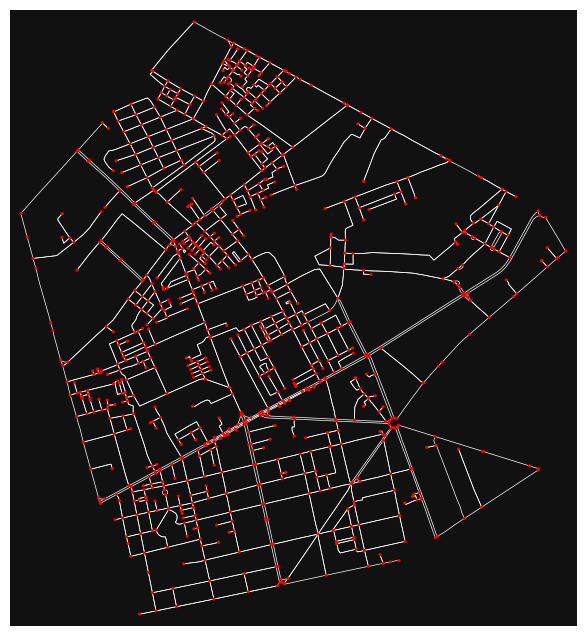

Số lượng nút giao :912
Số lượng đoạn đường:2142


In [ ]:
import osmnx as ox
import folium
import matplotlib.pyplot as plt
place = "District 10, Ho Chi Minh City"
A= ox.graph_from_place(place, network_type="drive")
fig,ax = ox.plot_graph(A, node_size=5 , node_color = "red", edge_color= "white", edge_linewidth=0.5)

stats= ox.basic_stats(A)
print(f"Số lượng nút giao :{stats['n']}")
print(f"Số lượng đoạn đường:{stats['m']}")



23.7

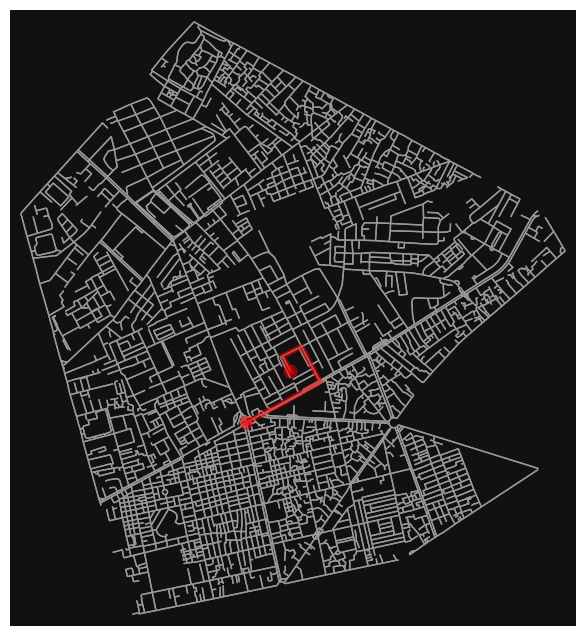

In [ ]:
import osmnx as ox
import networkx as nx
ox.settings.log_console = True
ox.settings.use_cache =True
place = "District 10, Ho Chi Minh City, Vietnam"
G_walk = ox.graph_from_place(place, network_type= "walk")

origin_coords = ox.geocode("279 Nguyen Tri Phuong, Hoa Hung, Ho Chi Minh City, Vietnam")
destination_coords = ox.geocode("Van Hanh Mall, Ho Chi Minh City, Vietnam")

orig_node= ox.distance.nearest_nodes(G_walk, origin_coords[1], origin_coords[0])
dest_node= ox.distance.nearest_nodes(G_walk, destination_coords[1], destination_coords[0])

route=nx.shortest_path(G_walk, orig_node, dest_node, weight="length")

fig,ax = ox.plot_graph_route(G_walk, route, node_size = 0)


23.8

In [ ]:
import folium
import osmnx as ox
import networkx as nx
import random
#Map quận 10
place ="District 10, Ho Chi Minh City, Vietnam"
G_drive= ox.graph_from_place(place, network_type="drive")
#Vị trí khách hàng
customer_points = (10.770226992325739, 106.66820031480081)
customer_location = ox.nearest_nodes(G_drive, customer_points[1], customer_points[0])
#Giả định các vị trí tài xế
driver_nodes=random.sample(list(G_drive.nodes),3)
#Tìm vị trí gần nhất
close_drive_node = None
shortest_dist = float("inf")
best_route = None

for driver_node in driver_nodes:
  try:
    route=nx.shortest_path(G_drive, driver_node, customer_location, weight="length")
    dist = nx.shortest_path_length(G_drive, driver_node, customer_location, weight="length" )
    if dist < shortest_dist:
      shortest_dist = dist
      close_drive_node = driver_node
      best_route = route
  except nx.NetworkXNoPath:
      continue

#Khởi tạo bản đồ
m=folium.Map(location=customer_points, zoom_start=14)
#Mark lại điểm khách hàng
folium.Marker(customer_points, popup="Vị trí" ,icon=folium.Icon(color="red")).add_to(m)
#Vị trí các xe đang trống
for node in driver_nodes:
  if node!= driver_nodes:
    driver_location=(G_drive.nodes[node]['y'], G_drive.nodes[node]['x'])
    folium.Marker(driver_location, popup="Vị trí tài xế", icon=folium.Icon(color="blue")).add_to(m)
if best_route:
  route_coords= [(G_drive.nodes[n]['y'], G_drive.nodes[n]['x']) for n in best_route]
  folium.PolyLine(locations= route_coords, color="green", weight=5, opacity=0.7).add_to(m)
  selected_drive= route_coords[0]
  folium.Marker(selected_drive, popup="Tài xế đang đến chỗ bạn", icon=folium.Icon(color="green")).add_to(m)
m



23.9


In [ ]:
import folium
import osmnx as ox
import networkx as nx
import random
#Map quận 10
place ="District 10, Ho Chi Minh City, Vietnam"
G= ox.graph_from_place(place, network_type="drive")
#Giả định các vị trí giao hàng
nodes_list=list(G.nodes)
delivery_nodes= random.sample(nodes_list, 5)
#Các vị trí trên bản đồ
start_nodes = delivery_nodes[0]
unvisited = delivery_nodes[1:]
current_node= start_nodes
full_path=[]
while unvisited:
  next_node= min(unvisited, key=lambda node: nx.shortest_path_length(G, current_node, node, weight="length"))
  full_path.extend(route[:-1])

  current_node= next_node
  unvisited.remove(next_node)
return_route = nx.shortest_path(G, current_node, start_nodes, weight="length")
full_path.extend(return_route)
#Trực quan hóa trên bản đồ
start_coords=(G.nodes[start_nodes]['y'], G.nodes[start_nodes]['x'])
m=folium.Map(start_coords, zoom_start=14)
for i, node in enumerate(delivery_nodes):
  color="red" if i==0 else "blue"
  popup= "Kho hàng" if i==0 else f"Đơn hàng: {i}"
  nodes = (G.nodes[node]['y'], G.nodes[node]['x'])
  folium.Marker(location =nodes, popup = popup, icon=folium.Icon(color=color)).add_to(m)

route_coords= [(G.nodes[n]['y'], G.nodes[n]['x']) for n in full_path]
folium.PolyLine(route_coords, color= "purple", weight=5, opacity=0.8).add_to(m)

m






In [ ]:
! pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 14.0 MB/s eta 0:00:00


23.10

In [ ]:
import folium
from folium.plugins import HeatMap
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import numpy as np
import osmnx as ox
#Đề ra các giới hạn cụ thể
velocity = ctrl.Antecedent(np.arange(0, 81, 1), 'velocity')
density = ctrl.Antecedent(np.arange(0, 101, 1), 'density')
risk= ctrl.Consequent(np.arange(0,101,1),"Khả năng đường bị tắc nghẽn")
#Tạo các hàm thành viên tự động
velocity.automf(3, names=["chậm","vừa", "nhanh"])
density.automf(3, names=["thưa", "vừa", "đông"])
#Đặt luật cho hàm risk
risk["Thấp"]= fuzz.trimf(risk.universe, [0,0,50] )
risk["Có khả năng"]= fuzz.trimf(risk.universe, [20,50,80])
risk["Cao"]=fuzz.trimf(risk.universe, [50,100,100])
#Định nghĩa tập luật
rules = [
    ctrl.Rule(velocity["chậm"]&density["đông"], risk["Cao"]),
    ctrl.Rule(velocity["nhanh"]&density["thưa"], risk["Thấp"]),
    ctrl.Rule(velocity["vừa"],risk["Có khả năng"]),
    ctrl.Rule(density["vừa"],risk["Có khả năng"])
]
risk_ctrl = ctrl.ControlSystem(rules)
risk_simulation=ctrl.ControlSystemSimulation(risk_ctrl)
risk_simulation.input['velocity'] = 10
risk_simulation.input['density'] = 96
risk_simulation.compute()
nguy_co_tac_duong= risk_simulation.output['Khả năng đường bị tắc nghẽn']
#Khởi tạo bản đồ quận 10
district_10 = [10.7736, 106.6672]
m=folium.Map(location=district_10, zoom_start=14)
#Giả lập 2 tuyến đường
tuyen_hien_tai = [[10.772, 106.660], [10.775, 106.665], [10.778, 106.670]]
tuyen_thay_the = [[10.772, 106.660], [10.768, 106.664], [10.770, 106.672]]
#nếu nguy cơ tắc đường> 70%, show đường thay thế
if nguy_co_tac_duong > 70:
  folium.PolyLine(tuyen_hien_tai, color="red", weight =7, opacity= 0.8, tooltip = "Tuyến đã tắc nghẽn").add_to(m)

  folium.PolyLine(tuyen_thay_the, color='green', weight =7, opacity=0.8, tooltip="Tuyến đường thay thế").add_to(m)
  #Giả sử người đi đường bị kẹt xe tại điểm giữa
  folium.Marker(
        location=tuyen_hien_tai[1],
        popup= f"Nguy cơ: {nguy_co_tac_duong:.2f}% - đổi hướng",
        icon=folium.Icon(color='red', icon='warning')
    ).add_to(m)
  folium.Marker(
        location=tuyen_thay_the[1],
        popup="Lộ trình thay thế",
        icon=folium.Icon(color='green',icon='check')
    ).add_to(m)
else:
  folium.PolyLine(tuyen_hien_tai, color="blue", weight=5, opacity=0.8).add_to(m)
m.fit_bounds(tuyen_hien_tai + tuyen_thay_the)
m

23.11

In [ ]:
import folium
from folium.plugins import HeatMap
from geopy.geocoders import Nominatim
import numpy as np
import pandas as pd
#Giả sử các địa điểm đông xe ra vào
location = {
    "Vạn Hạnh Mall": "11 Su Van Hanh, Hoa Hung, Ho Chi Minh City",
    "UEH_B": "279 Nguyen Tri Phuong, Dien Hong, Ho Chi Minh City",
    "Nhà thờ Tân Định": "289 Hai Ba Trung, Xuan Hoa, Ho Chi Minh City",
    "Chợ Nguyễn Tri Phương": "341 Su Van Hanh, Vuon Lai, Ho Chi Minh City"
}
geolocator=Nominatim(user_agent="colab-map-demo")
#Khởi tạo bản đồ
place = "Ho Chi Minh City"
location_main = geolocator.geocode(place)
latlng_org= (location_main.latitude, location_main.longitude)
m = folium.Map(latlng_org, zoom_start=15)
#Danh sách phục vụ tọa độ cho HeatMap:
all_coords = []
for name, address in location.items():
  try:
    address_location=geolocator.geocode(address)
    if address_location:
      latlng = (address_location.latitude, address_location.longitude)
      all_coords.append(latlng)
      folium.Marker(latlng, popup=name, icon=folium.Icon(color="red")).add_to(m)
  except:
    print(f"Không tìm thấy toạn độ cho{name}")
  #Thêm marker cho địa điểm
#Dự báo nhu cầu
def demand_predict_at_time(hour):
  #Giờ cao điểm (7h, 17h) tăng cao
  base_demand= 20+80*np.exp(-(hour - 17)**2/4) # Giả sử đang dự báo cho 17h
  return base_demand
current_hour=18
current_demand= demand_predict_at_time(current_hour)
#Tạo dữ liệu cho bản đồ heatmap
heatmap_data=[]
for coord in all_coords:
  local_weight=current_demand*np.random.uniform(0.5,1.5)
  heatmap_data.append([coord[0], coord[1], local_weight])
#Thêm heatmap
HeatMap(heatmap_data).add_to(m)

print(f"Bản đồ dự báo nhu cầu tại thành phố Hồ Chí Minh (các quận trung tâm) lúc {current_hour} giờ")
m




Bản đồ dự báo nhu cầu tại thành phố Hồ Chí Minh (các quận trung tâm) lúc 18 giờ


In [ ]:
!pip install ortools


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 9.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 6.33.6 which is incompatible

23.13

In [ ]:
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp
from geopy.distance import geodesic
import folium
#Khởi tạo bản đồ (tọa độ Việt Nam)
m=folium.Map(location=[10.7769, 106.7009], zoom_start=14)
#Kho và 5 khách hàng
locations = {
    "Kho": (10.7769, 106.7009),
    "Khách 1": (10.7800, 106.7100),
    "Khách 2": (10.7900, 106.7000),
    "Khách 3": (10.7700, 106.6800),
    "Khách 4": (10.7850, 106.7300),
    "Khách 5": (10.7650, 106.6900),
}
for name, coords in locations.items():
  folium.Marker(coords, popup=name, icon=folium.Icon(color="red")).add_to(m)
location_names = list(locations.keys())
coordinates=list(locations.values())
num_locations=len(coordinates)
#Tính ma trận
distance_matrix =[]
for from_coord in coordinates:
  row=[]
  for to_coord in coordinates:
    distance= geodesic(from_coord, to_coord).km
    row.append(int(distance*1000))
  distance_matrix.append(row)
#Hàm mô hình
def create_data_model():
  return {
      'distance_matrix': distance_matrix,
      'num_vehicles':1,
      'depot':0 #bắt đầu từ kho
  }
#Tạo dữ liệu
data=create_data_model()
#Tạo bài giải
manager=pywrapcp.RoutingIndexManager(len(data['distance_matrix']),
                                     data['num_vehicles'], data['depot'])
routing=pywrapcp.RoutingModel(manager)
#Hàm chi phí khoảng ách
def distance_callback(from_index, to_index):
  from_node = manager.IndexToNode(from_index)
  to_node=manager.IndexToNode(to_index)
  return data['distance_matrix'][from_node][to_node]
transit_callback_index=routing.RegisterTransitCallback(distance_callback)
routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)
#Thiết lập giải thuật giải
search_parameters= pywrapcp.DefaultRoutingSearchParameters()
search_parameters.first_solution_strategy=(
    routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
)
#Giải
solution=routing.SolveWithParameters(search_parameters)
#In kết quả
if solution:
  print("Lộ trình tối ưu")
  index=routing.Start(0)
  route=[]
  route_distance=0
  while not routing.IsEnd(index):
    node=manager.IndexToNode(index)
    print(f"->{location_names[node]}")
    route.append(coordinates[node])
    previous_index = index
    index=solution.Value(routing.NextVar(index))
    route_distance+=routing.GetArcCostForVehicle(previous_index, index, 0)
  print(f"->{location_names[manager.IndexToNode(index)]}")
  folium.PolyLine(route,color="green").add_to(m)
  print(f"Tổng khoảng cách:{route_distance/1000:.2f} km")
else:
  print("Không tìm được lời giải")
m

Lộ trình tối ưu
->Kho
->Khách 1
->Khách 4
->Khách 2
->Khách 3
->Khách 5
->Kho
Tổng khoảng cách:12.75 km


23.14

In [ ]:
import folium
import numpy as np
import pandas as pd
from datetime import datetime
#Bản đồ quận 10
fleet_data= {
    'Vehicle_ID':['Xe_1','Xe_2','Xe_3', 'Xe_4', 'Xe_5'],
    'Lat': [10.772, 10.775, 10.770, 10.780, 10.765],
    'Lon': [106.660, 106.665, 106.670, 106.662, 106.668],
    'Status': ['Trống', 'Đang chờ', 'Trống', 'Trống', 'Đang chờ']
}
data = pd.DataFrame(fleet_data)
order_loc=[10.774, 106.663]

def dispatch_vehicle(order_coords, fleet_df):
  available_vehicle = fleet_df[fleet_df['Status']=='Trống'].copy()

  if available_vehicle.empty:
    return None
  #Tính khoảng cách
  available_vehicle['dist']=available_vehicle.apply(
      lambda x: np.sqrt((x['Lat']- order_coords[0])**2+(x['Lon'] -order_coords[1])**2), axis=1
  )
  #Chọn xe gần nhất
  best_vehicle=available_vehicle.loc[available_vehicle['dist'].idxmin()]
  return best_vehicle['Vehicle_ID']

assigned_vehicle= dispatch_vehicle(order_loc, data)
#Bản đồ mô phỏng
m=folium.Map(location=[10.7736, 106.6672], zoom_start=15)
#đơn hàng  mới
folium.Marker(
    location=order_loc,
    popup="Đơn hàng mới",
    icon=folium.Icon(color="yellow")
).add_to(m)
#Mark xe công nghệ
for _, row in data.iterrows():
  color = "green" if row['Status']=="Trống" else "red"
  folium.Marker(location= [row['Lat'], row['Lon']], popup= row["Vehicle_ID"], icon=folium.Icon(color=color)).add_to(m)
#Nếu tìm được xe, vẽ đường chỉ dẫn
if assigned_vehicle:
  vehicle_row=data[data['Vehicle_ID']==assigned_vehicle].iloc[0]
  folium.PolyLine(
      [[vehicle_row['Lat'], vehicle_row['Lon']], order_loc],
       color = "blue"
  ).add_to(m)
print(f"Hệ thống điều phối thời gian thực")
print(f"Thời điểm:{datetime.now().strftime('%H:%M:%S')}")
print(f"Kết quả: Đã điều {assigned_vehicle} tới vị trí đơn hàng")

m




Hệ thống điều phối thời gian thực
Thời điểm:12:28:52
Kết quả: Đã điều Xe_1 tới vị trí đơn hàng


/tmp/ipykernel_8575/2520865627.py:35: UserWarning: color argument of Icon should be one of: {'white', 'darkred', 'purple', 'beige', 'darkpurple', 'blue', 'lightgreen', 'orange', 'red', 'gray', 'darkgreen', 'lightblue', 'black', 'darkblue', 'cadetblue', 'pink', 'green', 'lightred', 'lightgray'}.
  icon=folium.Icon(color="yellow")


23.15

In [ ]:
import folium
from geopy.geocoders import Nominatim
import numpy as np
#Cấu trúc hệ thống

class AI:
    def __init__(self):
        self.geolocator = Nominatim(user_agent="AI")
        self.depot = [10.7736, 106.6672]
    def get_risk_score(self, hour):
        return 20+75 *np.exp(-(hour-17)**2/4)
    def solve_delivery(self, destinations, current_hour):
        risk = self.get_risk_score(current_hour)

        m=folium.Map(location=self.depot, zoom_start=14)
        folium.Marker(self.depot, popup = "Kho", icon=folium.Icon(color="black")).add_to(m)
        print(f"Báo cáo hệ thống AI lúc {current_hour}h")
        print(f"Chỉ số rủi ro tắc nghẽn:{risk:.2f}%")

        coords = [self.depot]
        for name, address in destinations.items():
            loc=self.geolocator.geocode(address)
            if loc:
                pos=[loc.latitude, loc.longitude]
                coords.append(pos)
        folium.PolyLine(coords, color="blue").add_to(m)
        return m
#Thực thi ứng dụng
app= AI()
inventory ={
    "Khách 1": "279 Nguyen Tri Phuong, quan 10",
    "Khách 2": "254 Le Hong Phong, quan 10",
    "Khách 3": "11 Su Van Hanh, quan 10"
}
my_map=app.solve_delivery(inventory, current_hour=17)
my_map



Báo cáo hệ thống AI lúc 17h
Chỉ số rủi ro tắc nghẽn:95.00%
